Acknowledgements: I used Claude Code on some of the data processing and visualization work, but all of the free answer questions are my own work entirely. I also coded all of part 1 and 2 manually to begin, but vscode didn't save my work and I lost all of it so I redid it with Claude.


---

## **Part 1 — Exploring Different Modalities / Representations of Network Traffic**

Synthetic network traffic generation is useful for many applications such as dataset augmentation, network testing, and resource management. Many existing generation methods treat traffic generation as either a time-series prediction task or an autoregressive modeling task. In these approaches, models are trained directly on structured representations of packets—one common example is **nPrint**, a tabular format that encodes packet header fields from PCAP traces into machine-learning-friendly numerical vectors.

In an **nPrint**, each row represents one packet in a trace. The entire nPrint file (a large CSV) represents all packets of that trace in sequential order. Header fields are encoded using one-hot–like binary indicators (e.g., `1`, `0`, or `01`), making them easy to feed into ML models.

However, general-purpose ML models—even advanced time-series architectures and transformers—often struggle to capture the *complex dependencies* present in real network traffic:

* **Local dependencies**: relationships among columns within a single row (i.e., dependencies among header fields of a single packet).
* **Global dependencies**: relationships across rows (i.e., the evolution of packets within the same flow).
  For example: if the first packet of a flow uses TCP, the second packet in that same flow should also be TCP; sequence numbers, flags, and flow identifiers evolve in structured ways over time.

While sequential ML models struggle with these multi-scale dependencies, **vision models** (e.g., diffusion models) excel at capturing both local and global structure when data is presented spatially—like an image. By converting nPrint traces into 2D PNG images, we can take advantage of the strong representational capabilities of image models and generate synthetic traffic using visual generative approaches.

---

### **Your Task for Part 1**

In this part of the assignment, you will:

1. **Inspect the raw nPrint files** (found in the `real_nprints` directory).
2. **Understand how each CSV row and column corresponds to packet-level metadata.**
3. **Follow the provided conversion pipeline** that transforms these nPrint CSVs into PNG image representations suitable for use with diffusion models and other visual architectures.
4. **Take an already generated set of image-representation of images and convert them back into nprint representation for downstream task utilization**

This will help you understand why converting network traces to images can unlock generative modeling capabilities that traditional ML approaches struggle with.

Q1:
First, download and unzip the data you will need from (https://drive.google.com/file/d/1hY6nNXEYOwl1l-O_nCknO9xezcHr6ZXi/view?usp=sharing)
In your own words, describe how an nPrint CSV encodes a network trace.
Why might a 2D image representation capture structural relationships that a row-by-row CSV cannot?

nPrint encodes each packet into a fixed-width feature vector which is then segmented into per-protocol blocks (IPv4, TCP, UDP, ICMP, Payload). Every bit is encoded as one of three values; 1, 0, or -1. 1s and 0s represent the actual header bits, but headers that are shorter than the maximum size are padded with 0s. -1 marks a bit belonging to a header which simply isn't in the given packet type. 

Each row in the CSV represents a seperate packet. A 2D image representation would allow us to see local dependencies in the fields in each packet and also global relationships across rows (changes in packet attributes in a flow, for example).

Q2. Design a method for converting nPrint representations of traces (in the folder real_nprints) into image representations.
Your image representation should use only the first 1024 packets from each trace to avoid producing images that are too large.
Save the images into a folder called './nd_data/student_converted_images'

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.cm as cm
from PIL import Image

def nprint_to_image_array(path, max_packets=1024):
    df = pd.read_csv(path)

    # Drop the index column (e.g. "Unnamed: 0") so only header-bit columns remain
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    df = df.iloc[:max_packets, :]  # only the first 1024 packets
    arr = df.to_numpy(dtype=float)

    # Values are in {-1, 0, 1}; rescale to [0, 1] and map through a colormap
    # so local (within-row) and global (across-row) bit patterns show up as
    # visually distinct color bands/textures.
    norm = (arr + 1) / 2.0
    colored = (cm.viridis(norm) * 255).astype(np.uint8)
    return colored

def convert_nprints_to_images(input_dir="./nd_data/real_nprints",
                               output_dir="./nd_data/student_converted_images",
                               max_packets=1024):
    os.makedirs(output_dir, exist_ok=True)

    for path in glob.glob(os.path.join(input_dir, "*.nprint")):
        name = os.path.splitext(os.path.basename(path))[0]
        img_arr = nprint_to_image_array(path, max_packets)
        Image.fromarray(img_arr, "RGBA").save(os.path.join(output_dir, f"{name}.png"))

    print(f"Saved images to {output_dir}")

convert_nprints_to_images()


Saved images to ./nd_data/student_converted_images


In [2]:
# The following is a pre-defined script used in NetDiffusion that will convert all of the provided real nprints into image representations. Run this code and observe the output
!python ./scripts/nprint_to_png.py -i ./nd_data/real_nprints/ -o ./nd_data/real_traffic_images

Processing instagram_1024.nprint


❌ Failed to process instagram_1024.nprint: 'DataFrame' object has no attribute 'applymap'
Processing facebook_1024_7.nprint


❌ Failed to process facebook_1024_7.nprint: 'DataFrame' object has no attribute 'applymap'
Processing twitter_1024.nprint


❌ Failed to process twitter_1024.nprint: 'DataFrame' object has no attribute 'applymap'
Processing amazon_1024_1.nprint


❌ Failed to process amazon_1024_1.nprint: 'DataFrame' object has no attribute 'applymap'
Processing teams_1024_1.nprint


...

❌ Failed to process amazon_1024_3.nprint: 'DataFrame' object has no attribute 'applymap'
Processing netflix_1024_9.nprint


❌ Failed to process netflix_1024_9.nprint: 'DataFrame' object has no attribute 'applymap'
Processing meet_1024.nprint


❌ Failed to process meet_1024.nprint: 'DataFrame' object has no attribute 'applymap'
Processing youtube_1024_1.nprint


❌ Failed to process youtube_1024_1.nprint: 'DataFrame' object has no attribute 'applymap'
Processing facebook_1024_4.nprint


❌ Failed to process facebook_1024_4.nprint: 'DataFrame' object has no attribute 'applymap'


Q3: Now that you have seen how NetDiffusion converts nPrints into images, compare their method with the approach you designed in Q2. What are the advantages and disadvantages of each, especially in terms of what might help or hinder a vision model’s ability to learn?

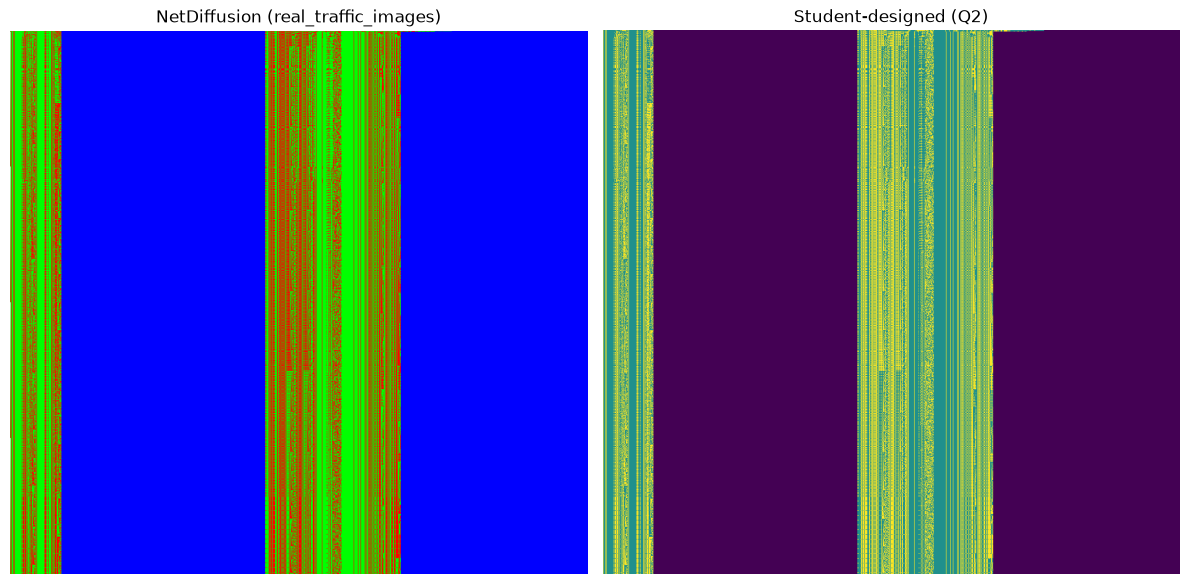

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

real_img = Image.open("./nd_data/real_traffic_images/amazon_1024_1.png")
student_img = Image.open("./nd_data/student_converted_images/amazon_1024_1.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(real_img)
axes[0].set_title("NetDiffusion (real_traffic_images)")
axes[0].axis("off")

axes[1].imshow(student_img)
axes[1].set_title("Student-designed (Q2)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


The NetDiffusion method is basically the same as mine - drop the header from the raw nPrint files as well as the indices, then create an image where each pixel in a given row corresponds to the corresponding bits in the nPrint, then stack the rows in temporal order (how the file is read) to show the packet flow. Whereas I used matplotlib's viridis color scheme, where `-1` becomes purple, `0` becomes blue-green, and `1` becomes bright green after normalizing the values in the range `[0, 1]`, NetDiffusion uses pure RGB colors, displaying `-1` as `(0, 0, 255)` blue, `0` as `(0, 255, 0)` green, and `-1` as `(255, 0, 0)` red. Assuming that each RGB channel is normalized from `[0, 255]` to `[0, 1]` before being put into the vision model, the NetDiffusion method would provide the model with what is pretty much one hot encoding for each possible bit per pixel, which could possibly increase performance or give the model a head start, since each nPrint bit value would be very easy to differentiate. 


---

## **Part 2 — Converting Generated Images Back Into Usable Format**

In the first part of the assignment, you explored how network traces in nPrint format can be transformed into image representations suitable for vision-based generative models. In Part 2, we focus on the reverse process: taking synthetic images produced by these models and converting them back into structured network representations.

This step is crucial because real-world applications do not operate on images—they require valid, interpretable packet traces that can be analyzed, replayed, or integrated into downstream tools.

---

### **Your Task for Part 2**

In this part of the assignment, you will:

1. **Convert generated images back into the original nPrint representation.**
   You will follow a scripted pipeline that translates pixel intensities and color channels back into binary header fields, reconstructing the packet-level structure of the trace.

2. **Apply essential post-processing techniques to correct errors introduced by diffusion models.**
   Generated images are rarely perfect—vision models may introduce color drift, pixel misalignment, noise, or structural artifacts.
   You will observe how heuristic correction, formatting enforcement, and reconstruction steps ensure that the converted nPrints become:

   * syntactically valid,
   * structurally consistent,
   * and replayable.

Across this section, your goal is to understand **why the reverse transformation is fragile**, which types of artifacts break reversibility, and how post-processing logic helps repair or compensate for generative errors.

For simplicity of this assignment, we have trainined and generated the images for you. If you have sufficient GPU access and want to try fine-tuning the model and generating the images yourself, feel free to take a look at the public repo (https://github.com/noise-lab/NetDiffusion).


Q4: We have taken the images converted by NetDiffusion and trained a LoRA-fine-tuned Stable Diffusion model (with ControlNet) to generate synthetic traffic images for you. These generated samples are stored in generated_traffic_images/.
Compare these generated images visually with the real images you saw earlier in real_traffic_images/.

Do you notice anything different between the real and generated traffic images? What immediately stands out as potentially problematic if we attempt to convert these generated images back into nPrint format? (Descriptive Only)

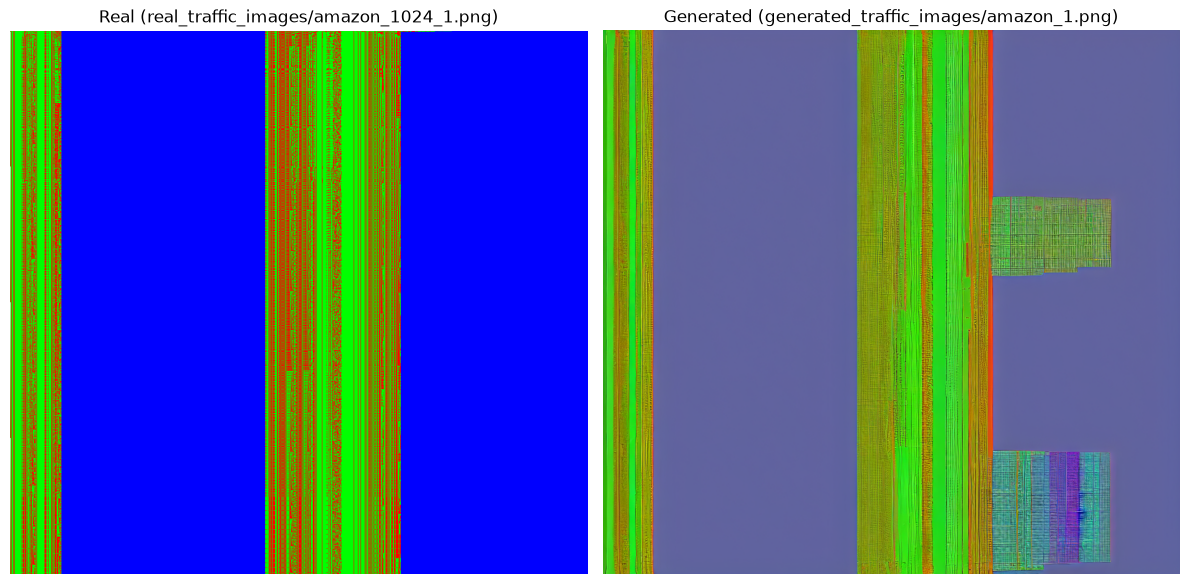

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

real_img = Image.open("./nd_data/real_traffic_images/amazon_1024_1.png")
generated_img = Image.open("./nd_data/generated_traffic_images/amazon_1.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(real_img)
axes[0].set_title("Real (real_traffic_images/amazon_1024_1.png)")
axes[0].axis("off")

axes[1].imshow(generated_img)
axes[1].set_title("Generated (generated_traffic_images/amazon_1.png)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


The generated image has muddled colors. While the original nPrint image representation has bits as clear RGB, where one channel is `255` and the others are always `0`, it seems that blue has shifted to a sort of lilac color in the generated image and red and green have become blurred a bit. Since the colors aren't pure RGB, we can't naively reconvert them back to nPrints by matching colors to bits without any processing. The generated image also seems to have some wobbly vertical lines in it that should be straight, but I don't know how important these actually are.

Q5: If you were to design a method to convert generated images back into nPrints, how would you do it? Explain your approach and describe how your method addresses the concerns you raised in Q4. (Descriptive only)

I would begin by ceiling the colors - if a pixel has the more blue in it than red and green, something like `(52, 64, 195)`, then replace it with pure `(0, 0, 255)` blue. Do this same process for every pixel in the image so the colors not being pure isn't an issue anymore. Then, we can just iterate through each row in the image, match pure RGB colors to bits, and put the bits in the nPrint format.

Below are a set of pre-written scripts that perform the necessary post-generation augmentation and processing on the synthetic images you obtained from the diffusion model. These scripts handle tasks such as color normalization/augmentation and conversion from generated images back into nPrint format.
(The PCAP step is optional — you may run it if you are interested in observing or replaying the reconstructed traffic.)

In [5]:
# Step 1: Color Augmentation
!python ./scripts/color_processor.py \
  --input_dir="./nd_data/generated_traffic_images" \
  --output_dir="./nd_data/color_corrected_generated_traffic_images"

Processed 100 images.


In [6]:
# Step 2: Image-to-nPrint Conversion
!python ./scripts/image_to_nprint.py \
  --org_nprint ./scripts/column_example.nprint \
  --input_dir ./nd_data/color_corrected_generated_traffic_images \
  --output_dir ./nd_data/generated_nprint

Processing ./nd_data/color_corrected_generated_traffic_images/facebook_6.png with size 1088 x 1024


Saved ./nd_data/generated_nprint/facebook_6.nprint


Processing ./nd_data/color_corrected_generated_traffic_images/twitter_7.png with size 1088 x 1024


Saved ./nd_data/generated_nprint/twitter_7.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/instagram_5.png with size 1088 x 1024


Saved ./nd_data/generated_nprint/instagram_5.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/meet_3.png with size 1088 x 1024


...

Saved ./nd_data/generated_nprint/meet_7.nprint


Processing ./nd_data/color_corrected_generated_traffic_images/meet_5.png with size 1088 x 1024


Saved ./nd_data/generated_nprint/meet_5.nprint


Processing ./nd_data/color_corrected_generated_traffic_images/zoom_0.png with size 1088 x 1024


Saved ./nd_data/generated_nprint/zoom_0.nprint
Done! Converted 100 .png files into .nprint format.


Q6: You may now read through the provided scripts in color_processor.py (color augmentation / normalization) and image_to_nprint.py (image → nPrint reconstruction).
How do the post-processing methods implemented in these scripts compare to the approach you proposed in Q5?
Describe the pros and cons of both methods and highlight any differences in design philosophy, robustness, or assumptions.

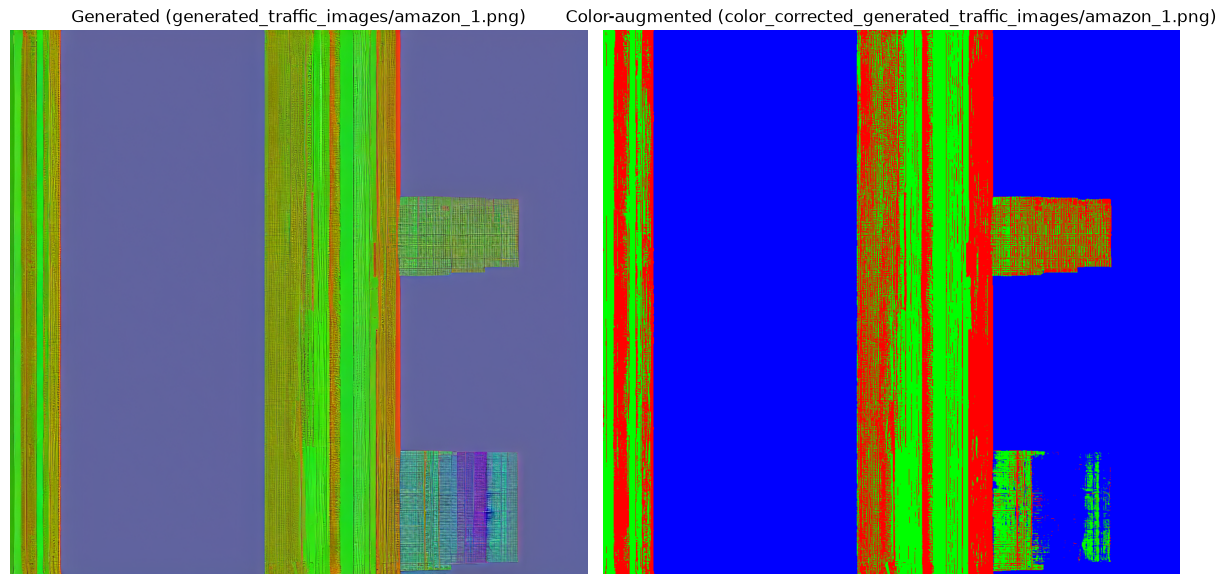

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

generated_img = Image.open("./nd_data/generated_traffic_images/amazon_1.png")
color_corrected_img = Image.open("./nd_data/color_corrected_generated_traffic_images/amazon_1.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(generated_img)
axes[0].set_title("Generated (generated_traffic_images/amazon_1.png)")
axes[0].axis("off")

axes[1].imshow(color_corrected_img)
axes[1].set_title("Color-augmented (color_corrected_generated_traffic_images/amazon_1.png)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


The scripts pretty much follow what I suggested in the last question. The color processor script iterates through each pixel and makes it red, green, or blue depending on a threshold. The thresholding mechanicsm is a bit weird, though, and I'm wondering if there's a bug in the script. Take the condition for the pixel being set as red initially, for example: 

```if r > r_red and g < g_red and b < b_red:``` set the pixel to red,

but the script defines `r_red = 0`, `g_red = 160`, and `b_red = 100`, so a pixel being set red isn't dependent on the dominant color being red, it's just dependent on the other colors not being strong enough. The branch could misfire on pixels that aren't actually red. Take, for example `r=50, g=150, b=90`. Green is the largest channel here, but the pixel would be classified as red. 

If all of the first three threshold conditions fail, which are similar for each color, the processor simply determines color based on which channel is the largest, which is what I proposed to do initially. It could be the case that the "label red if green and blue are not very strong" method is best because the color palette the model generates, or something like that, but I do wonder if the possible misfires are worth it. 

`image_to_nprint.py` just reverse pattern matches on the processed RGB pixels. Column names come from a reference file, not the image itself (images don't carry column headers) and indices are created accorrding to how many rows into the image we are. Bits are already aligned with the column that they're meant to be in. This method is similar to what I suggested.




---

# **Part 3 — Using Real and Synthetic nPrints for Application Classification**

In the previous parts, you learned how network traces can be converted between nPrint and image representations, generated using diffusion models, and reconstructed back into nPrint format.
Now, you will evaluate how useful these generated nPrints are for downstream **machine learning tasks**.

Each nPrint file—whether real or generated—is labeled with the **application** that produced the traffic (e.g., `amazon_1.nprint` means this sample came from Amazon traffic).
In this section, you will treat each **entire nPrint file as a single sample** and build a simple ML pipeline to classify application labels.

To simplify the task, you will restrict your model to use **only the first 3 packets** (3 rows) from each nPrint.
This mimics “early packet classification,” where only the beginning of a flow is available.

---


Q7:

You now have access to both `real_nprints/` and `generated_nprint/`.
Notice that in both directories, files are labeled using the application associated with that nPrint (e.g., `amazon_1.nprint`).
Treat each **nPrint file** as one sample.

**Design an ML pipeline that trains a model using *synthetic nPrints* (from `generated_nprint/`) and evaluates its performance on *real nPrints* (from `real_nprints/`) to predict the correct application label.**

Your pipeline should:

1. Use only the **first 3 packets (first 3 rows)** of each nPrint file as input features.
2. Train a classifier on real data.
3. Test the classifier on generated data.
4. Report how well the classifier performs.

We have already written the script to load the real and generated nprints into DataFrame for you.

In [8]:
import os
import glob
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# Safe conversion for nPrint cell
# ---------------------------------------------------------------
def safe_convert(x):
    if pd.isna(x):
        return 0
    x = str(x).strip()

    if x in ["0", "1", "-1"]:
        return int(x)

    if all(c in "01" for c in x) and len(x) <= 16:
        return int(x, 2)

    if x.lstrip("-").isdigit():
        return int(x)

    return 0


# ---------------------------------------------------------------
# Get original column names from a reference nPrint
# ---------------------------------------------------------------
def get_original_columns(example_path="nd_data/real_nprints"):
    first_file = glob.glob(os.path.join(example_path, "*.nprint"))[0]

    df = pd.read_csv(first_file)

    # Drop index column if present (like "Unnamed: 0")
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    return list(df.columns)


# ---------------------------------------------------------------
# Load nPrint → first 3 rows → flatten with prefixed column names
# ---------------------------------------------------------------
def load_nprint_with_colnames(path, base_cols, num_rows=3):
    df = pd.read_csv(path, dtype=str, low_memory=False)

    # Drop "Unnamed: 0" if present
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    df = df.iloc[:num_rows, :]            # first 3 packets  
    df = df.map(safe_convert)             # clean convert  

    # Build prefixed column names
    pkt_cols = []
    for pkt in range(1, num_rows + 1):
        pkt_cols.extend([f"pkt{pkt}_{c}" for c in base_cols])

    # Flatten 3×columns into 1 vector
    flat = df.values.flatten()

    return flat, pkt_cols


# ---------------------------------------------------------------
# Load entire directory into a DataFrame (with labels)
# ---------------------------------------------------------------
def load_directory_as_df(directory, base_cols):
    rows = []
    labels = []
    colnames_set = None

    for path in glob.glob(os.path.join(directory, "*.nprint")):
        label = os.path.basename(path).split("_")[0]

        flat, cn = load_nprint_with_colnames(path, base_cols)
        rows.append(flat)
        labels.append(label)

        if colnames_set is None:
            colnames_set = cn   # only set once

    df = pd.DataFrame(rows, columns=colnames_set)
    df["label"] = labels
    return df


# ---------------------------------------------------------------
# FINAL: Load real + synthetic DataFrames
# ---------------------------------------------------------------
base_cols = get_original_columns("nd_data/real_nprints")

df_synth = load_directory_as_df("nd_data/generated_nprint", base_cols)
df_real  = load_directory_as_df("nd_data/real_nprints", base_cols)

print("Synthetic DF:", df_synth.shape)
print(df_synth.head())

print("\nReal DF:", df_real.shape)
print(df_real.head())


Synthetic DF: (100, 3265)
   pkt1_ipv4_ver_0  pkt1_ipv4_ver_1  pkt1_ipv4_ver_2  pkt1_ipv4_ver_3  \
0                0                0                0                0   
1                1                0                0                0   
2                1                0                0                0   
3                1                0                0                0   
4                0                0                0                0   

   pkt1_ipv4_hl_0  pkt1_ipv4_hl_1  pkt1_ipv4_hl_2  pkt1_ipv4_hl_3  \
0               0               0               0               0   
1               0               0               0               0   
2               0               0               0               1   
3               0               0               0               1   
4               0               0               1               1   

   pkt1_ipv4_tos_0  pkt1_ipv4_tos_1  ...  pkt3_icmp_roh_23  pkt3_icmp_roh_24  \
0                0                0  ...

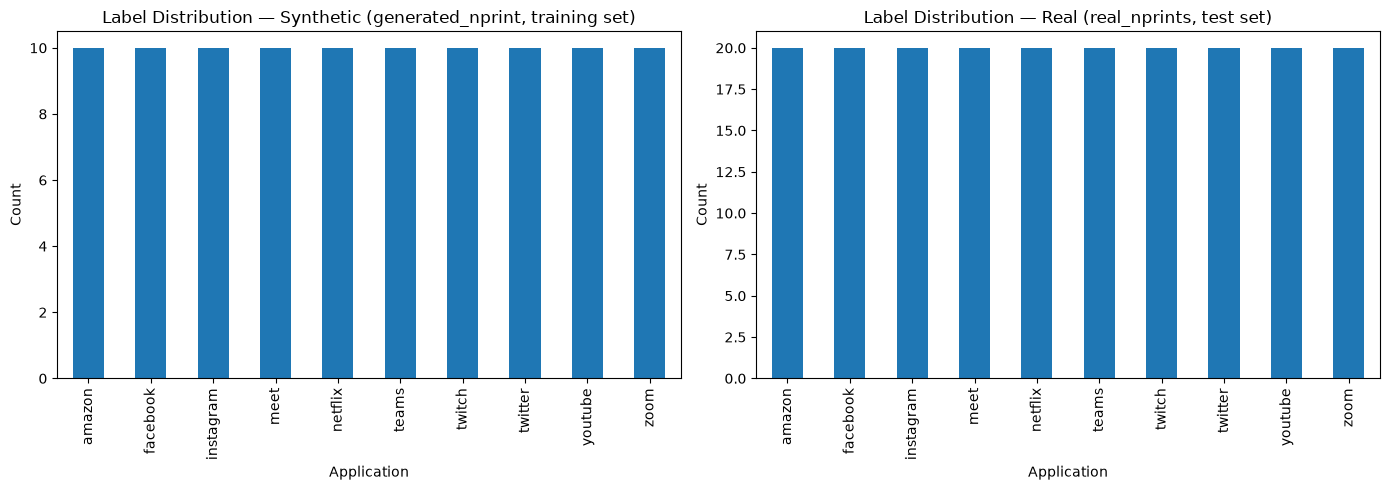

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_synth["label"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Label Distribution — Synthetic (generated_nprint, training set)")
axes[0].set_xlabel("Application")
axes[0].set_ylabel("Count")

df_real["label"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Label Distribution — Real (real_nprints, test set)")
axes[1].set_xlabel("Application")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [10]:
import os
import joblib
from sklearn.ensemble import RandomForestClassifier

# Train on the synthetic (generated) nPrints; every column except "label" is a feature
feature_cols = [c for c in df_synth.columns if c != "label"]

X_train = df_synth[feature_cols]
y_train = df_synth["label"]

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "q7_random_forest.joblib")

# Save feature_cols alongside the model so downstream cells apply columns
# in the exact same order the model was trained on.
joblib.dump({"model": clf, "feature_cols": feature_cols}, checkpoint_path)

print(f"Saved trained model to {checkpoint_path}")


Saved trained model to ./checkpoints/q7_random_forest.joblib


In [11]:
import joblib

checkpoint_path = "./checkpoints/q7_random_forest.joblib"
checkpoint = joblib.load(checkpoint_path)

clf = checkpoint["model"]
feature_cols = checkpoint["feature_cols"]

print(f"Loaded model from {checkpoint_path}")
print(clf)


Loaded model from ./checkpoints/q7_random_forest.joblib
RandomForestClassifier(n_estimators=200, random_state=42)


              precision    recall  f1-score   support

      amazon       0.00      0.00      0.00        20
    facebook       0.00      0.00      0.00        20
   instagram       0.50      0.10      0.17        20
        meet       1.00      0.05      0.10        20
     netflix       0.50      0.10      0.17        20
       teams       0.21      1.00      0.35        20
      twitch       0.00      0.00      0.00        20
     twitter       0.21      1.00      0.35        20
     youtube       0.50      0.05      0.09        20
        zoom       0.00      0.00      0.00        20

    accuracy                           0.23       200
   macro avg       0.29      0.23      0.12       200
weighted avg       0.29      0.23      0.12       200

Macro Precision: 0.2923
Macro Recall:    0.2300
Macro F1:        0.1218


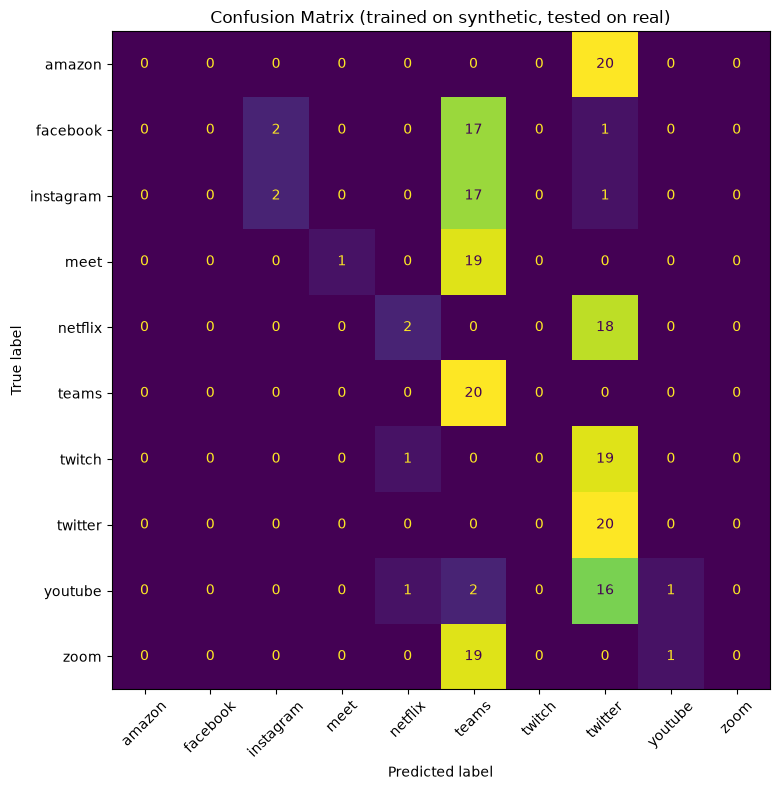

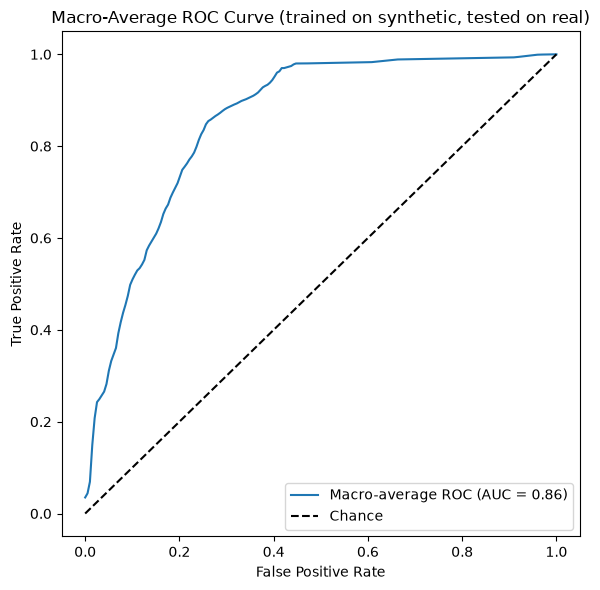

Macro-average AUC: 0.8572


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

# Evaluate the synthetic-trained model on REAL nPrints
X_test = df_real[feature_cols]
y_test = df_real["label"]

y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)
classes = clf.classes_

# --- Precision / Recall / F1 ---
print(classification_report(y_test, y_pred, labels=classes, zero_division=0))

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=classes, average="macro", zero_division=0
)
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall:    {recall_macro:.4f}")
print(f"Macro F1:        {f1_macro:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix (trained on synthetic, tested on real)")
plt.tight_layout()
plt.show()

# --- Macro-average ROC curve + AUC (one-vs-rest, since this is multiclass) ---
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

fpr_grid = np.linspace(0.0, 1.0, 200)
mean_tpr = np.zeros_like(fpr_grid)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    mean_tpr += np.interp(fpr_grid, fpr, tpr)
mean_tpr /= n_classes

macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_grid, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.2f})")
ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Macro-Average ROC Curve (trained on synthetic, tested on real)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Macro-average AUC: {macro_auc:.4f}")


Performance is not good. At first I thought it could be due to class imbalance, but the labels are actually perfectly evenly distributed in the train and test set. This result seems to be a classic case of a model trained on synthetic data failing to generalize to the real world, as shown by the low macro precision, recall, and f1-scores, which are about `0.29`, `0.23`, and `0.12`, respectively. 